# Section 1: Feature Engineering & Model Tuning

**Objective:** Improve model performance through feature engineering and hyperparameter tuning.

This notebook:
- Loads a *student performance* dataset.
- Builds a **baseline** model with simple features.
- Performs **feature engineering** to add informative signals.
- Uses **GridSearchCV** to tune a `RandomForestClassifier`.
- Compares baseline vs. tuned model performance.


In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# Ensure reproducibility
RANDOM_STATE = 42

# Load dataset
data_path = Path("student_performance.csv")  # keep this notebook and CSV in the same folder
df = pd.read_csv(data_path)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Rows: 500, Columns: 12


,math,physics,chemistry,english,cs,attendance,hours_studied,extracurricular,school_type,prep_course,overall_score,passed
0,73.7,85.7,65.2,66.3,69.0,89.4,13.7,3,Public,Yes,52.62,0
1,57.5,79.6,55.8,65.8,66.7,87.0,12.1,2,Public,No,61.11,1
2,79.0,58.6,60.2,85.3,78.8,93.1,15.9,3,Public,No,69.25,1
3,81.3,48.5,74.9,75.3,76.8,88.9,5.4,4,Public,Yes,43.59,0
4,46.6,29.5,66.0,69.9,58.5,94.7,9.2,2,Public,Yes,27.82,0


## Quick EDA
We'll check some basic info and target balance.


In [2]:
df.describe(include='all')

,math,physics,chemistry,english,cs,attendance,hours_studied,extracurricular,school_type,prep_course,overall_score,passed
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500,500,500.000000,500.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Public,No,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,359,287,NaN,NaN
mean,69.819800,67.398200,65.924600,70.409800,73.936800,85.445400,10.058400,2.474000,NaN,NaN,46.617360,0.190000
std,11.455052,13.180861,14.246738,10.021026,11.093959,7.892867,2.896572,1.672998,NaN,NaN,16.614949,0.392694
min,39.200000,20.600000,24.600000,41.500000,40.300000,62.100000,1.800000,0.000000,NaN,NaN,0.000000,0.000000
25%,61.975000,58.550000,56.700000,64.075000,66.375000,79.900000,8.075000,1.000000,NaN,NaN,36.070000,0.000000
50%,70.050000,68.100000,66.000000,70.650000,74.400000,85.250000,10.100000,2.000000,NaN,NaN,46.675000,0.000000
75%,77.025000,75.775000,75.200000,77.100000,81.225000,91.325000,12.100000,4.000000,NaN,NaN,57.035000,0.000000


In [3]:
df['passed'].value_counts(normalize=True).rename('proportion')

passed
0    0.81
1    0.19
Name: proportion, dtype: float64

## Baseline: Simple Features
We'll start with raw features (no engineered features) and a basic `RandomForestClassifier` with default parameters.


Baseline Accuracy: 0.8400

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       101
           1       0.83      0.21      0.33        24

    accuracy                           0.84       125
   macro avg       0.84      0.60      0.62       125
weighted avg       0.84      0.84      0.80       125



<Figure size 640x480 with 0 Axes>

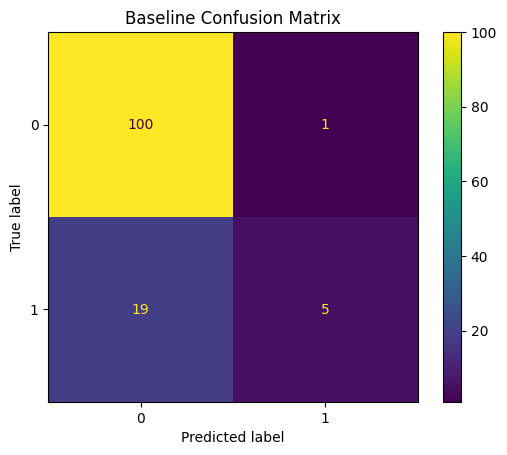

In [4]:
# Feature/target split
base_features_num = ['math','physics','chemistry','english','cs','attendance','hours_studied','extracurricular']
base_features_cat = ['school_type','prep_course']

X_base = df[base_features_num + base_features_cat]
y = df['passed']

# Preprocess: scale numeric (optional for trees but keeps parity), one-hot for categoricals
preprocess_base = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), base_features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), base_features_cat)
    ]
)

baseline_clf = Pipeline(steps=[
    ('preprocess', preprocess_base),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

baseline_clf.fit(X_train_b, y_train_b)
y_pred_b = baseline_clf.predict(X_test_b)

acc_b = accuracy_score(y_test_b, y_pred_b)
print(f"Baseline Accuracy: {acc_b:.4f}\n")
print(classification_report(y_test_b, y_pred_b))

cm_b = confusion_matrix(y_test_b, y_pred_b)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b)
plt.figure()
disp_b.plot(values_format='d')
plt.title('Baseline Confusion Matrix')
plt.show()


## Feature Engineering
We create additional features that may improve separability:

- `total_score`: sum of subject scores
- `avg_score`: average of subject scores
- `score_std`: standard deviation across subjects
- `best3_total`: sum of the top 3 subject scores
- `study_efficiency`: `hours_studied * attendance`
- `eng_math_gap`: `english - math`

We'll then rebuild the pipeline and re-evaluate.


Post-Feature-Engineering Accuracy: 0.8160

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       101
           1       0.53      0.42      0.47        24

    accuracy                           0.82       125
   macro avg       0.70      0.66      0.68       125
weighted avg       0.80      0.82      0.81       125



<Figure size 640x480 with 0 Axes>

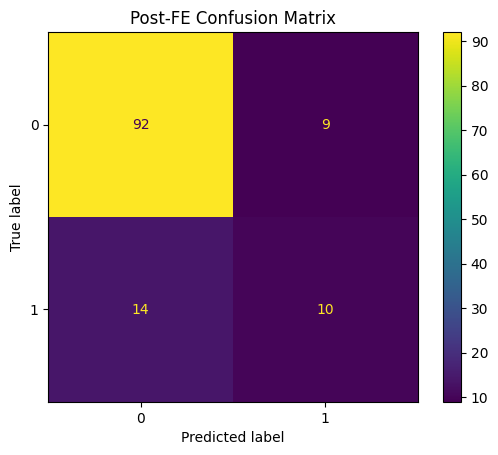

In [5]:
# Create engineered features
subject_cols = ['math','physics','chemistry','english','cs']

df_fe = df.copy()
df_fe['total_score'] = df_fe[subject_cols].sum(axis=1)
df_fe['avg_score'] = df_fe[subject_cols].mean(axis=1)
df_fe['score_std'] = df_fe[subject_cols].std(axis=1)
df_fe['best3_total'] = df_fe[subject_cols].apply(lambda r: np.sort(r.values)[-3:].sum(), axis=1)
df_fe['study_efficiency'] = df_fe['hours_studied'] * df_fe['attendance']
df_fe['eng_math_gap'] = df_fe['english'] - df_fe['math']

fe_num = ['attendance','hours_studied','extracurricular','total_score','avg_score','score_std','best3_total','study_efficiency','eng_math_gap'] + subject_cols
fe_cat = ['school_type','prep_course']

X_fe = df_fe[fe_num + fe_cat]
y = df_fe['passed']

preprocess_fe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), fe_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), fe_cat)
    ]
)

fe_clf = Pipeline(steps=[
    ('preprocess', preprocess_fe),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fe, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

fe_clf.fit(X_train_f, y_train_f)
y_pred_f = fe_clf.predict(X_test_f)

acc_f = accuracy_score(y_test_f, y_pred_f)
print(f"Post-Feature-Engineering Accuracy: {acc_f:.4f}\n")
print(classification_report(y_test_f, y_pred_f))

cm_f = confusion_matrix(y_test_f, y_pred_f)
disp_f = ConfusionMatrixDisplay(confusion_matrix=cm_f)
plt.figure()
disp_f.plot(values_format='d')
plt.title('Post-FE Confusion Matrix')
plt.show()


## Hyperparameter Tuning with GridSearchCV
We tune key `RandomForestClassifier` parameters using 5-fold cross-validation.


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Params:
 {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Accuracy: 0.8507

Tuned Model Test Accuracy: 0.8480

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       101
           1       0.67      0.42      0.51        24

    accuracy                           0.85       125
   macro avg       0.77      0.68      0.71       125
weighted avg       0.83      0.85      0.83       125



<Figure size 640x480 with 0 Axes>

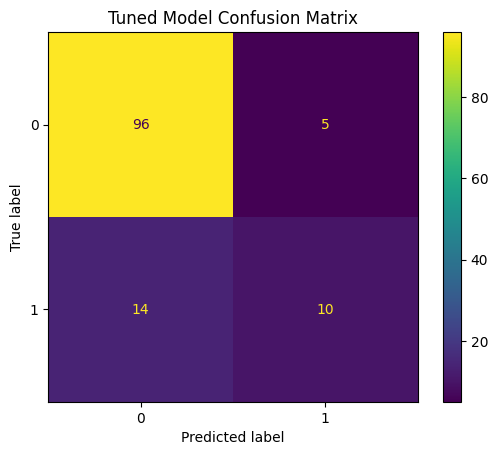

In [6]:
param_grid = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth': [None, 8, 12, 16],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(
    estimator=Pipeline(steps=[('preprocess', preprocess_fe), ('model', RandomForestClassifier(random_state=RANDOM_STATE))]),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_f, y_train_f)
print("Best Params:\n", grid.best_params_)
print(f"Best CV Accuracy: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_f)

acc_tuned = accuracy_score(y_test_f, y_pred_tuned)
print(f"\nTuned Model Test Accuracy: {acc_tuned:.4f}\n")
print(classification_report(y_test_f, y_pred_tuned))

cm_t = confusion_matrix(y_test_f, y_pred_tuned)
disp_t = ConfusionMatrixDisplay(confusion_matrix=cm_t)
plt.figure()
disp_t.plot(values_format='d')
plt.title('Tuned Model Confusion Matrix')
plt.show()


## Comparison Summary
Below we print baseline vs. feature-engineered vs. tuned model accuracies for quick reference.


In [7]:
print({
    'baseline_accuracy': acc_b,
    'post_fe_accuracy': acc_f,
    'tuned_accuracy': acc_tuned
})

{'baseline_accuracy': 0.84, 'post_fe_accuracy': 0.816, 'tuned_accuracy': 0.848}


### Deliverable
An improved model accuracy and performance via:
- Thoughtful **feature engineering**
- **GridSearchCV** for hyperparameter tuning

You can extend the grid, add more features, or try other estimators (e.g., Gradient Boosting, Logistic Regression) to explore further gains.
